# 02 — Cointegration Funnel + Multiple Testing + Copula

คู่กับ **Part II** (`practice-part2.html`) — สร้างหลักฐานที่ reproduce ได้ 3 อย่าง:

1. Engle-Granger + ADF **แยกคู่ที่ cointegrate จริงออกจากคู่ที่ไม่ cointegrate** ได้จริงไหม (ทดสอบทั้งสองแบบ)
2. **Multiple testing**: ถ้าสแกนคู่ที่ไม่มีความสัมพันธ์จริงหลายร้อยคู่ ที่ α=0.05 จะเจอ "คู่ผี" ที่ผ่าน ADF กี่คู่ — เทียบกับตัวเลข 500×0.05=25 ที่หนังสืออ้างไว้
3. **Copula Mispricing Index** แบบมือ (Gaussian copula) — โค้ดที่รันได้จริงโดยไม่ต้องพึ่ง library หนัก

⚠️ ใช้ข้อมูลจำลอง (เหตุผลเดียวกับโน้ตบุ๊ก 01 — network policy ของ sandbox บล็อก data provider การเงินทุกเจ้า)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint
from scipy import stats
from simdata import simulate_cointegrated_pair

pd.set_option("display.precision", 4)


## 2.1 Engle-Granger บนคู่ที่ cointegrate จริง vs คู่ที่ไม่ cointegrate

**คู่ A** มาจาก `simulate_cointegrated_pair` (มี OU spread จริง = cointegrate โดยสร้าง)
**คู่ B** คือ 2 random walk อิสระจากกันโดยสิ้นเชิง (ไม่มีความสัมพันธ์ใด ๆ) — ตัวแทนของ "spurious pair"

⚠️ **จุดสำคัญที่ต้องระวังตั้งแต่บรรทัดแรก:** ทดสอบ residual จาก OLS ด้วย `adfuller()` ตรง ๆ (ใช้ critical value ของ ADF ทั่วไป) เป็น**วิธีที่ผิด** — residual ที่มาจากการ fit regression แล้ว จะดู "นิ่ง" เกินจริงเสมอ (เป็นผลพวงของ spurious-regression ที่ Part I §1.3 เตือนไว้) ต้องใช้ **`statsmodels.tsa.stattools.coint()`** ซึ่งใช้ critical value ที่ปรับสำหรับ Engle-Granger โดยเฉพาะ (MacKinnon) — โค้ดข้างล่างเทียบให้เห็นทั้งสองแบบ


In [2]:
def engle_granger(y, x):
    """Correct Engle-Granger: beta from OLS, p-value from coint() (proper EG critical values)."""
    X = sm.add_constant(x)
    ols = sm.OLS(y, X).fit()
    resid = ols.resid
    _, p_coint, _ = coint(y, x)
    return ols.params.iloc[1], p_coint, resid

def naive_adf_on_residual(y, x):
    """WRONG but common mistake: plain adfuller() on the OLS residual (wrong critical values)."""
    X = sm.add_constant(x)
    resid = sm.OLS(y, X).fit().resid
    _, p, *_ = adfuller(resid, autolag="AIC")
    return p

# --- Pair A: genuinely cointegrated (by construction) ---
df_coint = simulate_cointegrated_pair(n=1000, beta_true=1.3, beta_drift="const",
                                       obs_noise_a=0.3, obs_noise_b=0.3, seed=11)
beta_a, p_a, resid_a = engle_granger(df_coint["A_obs"], df_coint["B_obs"])

# --- Pair B: two INDEPENDENT random walks (no relationship at all) ---
rng = np.random.default_rng(99)
rw1 = np.cumsum(rng.normal(0, 1, 1000)) + 100
rw2 = np.cumsum(rng.normal(0, 1, 1000)) + 100
beta_b, p_b, resid_b = engle_granger(pd.Series(rw1), pd.Series(rw2))
p_b_naive = naive_adf_on_residual(pd.Series(rw1), pd.Series(rw2))

print(f"Pair A (built cointegrated):    beta={beta_a:.3f}   coint() p-value={p_a:.4f}   {'PASS (p<0.05)' if p_a < 0.05 else 'fail'}")
print(f"Pair B (independent, spurious): beta={beta_b:.3f}   coint() p-value={p_b:.4f}   {'PASS (p<0.05) <- false positive' if p_b < 0.05 else 'fail (correctly rejected)'}")
print(f"Pair B same data, WRONG test    : naive adfuller-on-residual p-value={p_b_naive:.4f}   {'PASS <- false positive' if p_b_naive < 0.05 else 'fail'}")


Pair A (built cointegrated):    beta=1.400   coint() p-value=0.0001   PASS (p<0.05)
Pair B (independent, spurious): beta=0.178   coint() p-value=0.0376   PASS (p<0.05) <- false positive
Pair B same data, WRONG test    : naive adfuller-on-residual p-value=0.0096   PASS <- false positive


Pair A ควรผ่าน (p < 0.05) เพราะเราสร้างให้ cointegrate จริง · Pair B ใช้ `coint()` (วิธีถูก) อาจผ่านหรือไม่ผ่านแบบสุ่มในอัตราที่ถูกต้อง (~5%) — แต่สังเกตว่า p-value จาก `naive adfuller-on-residual` (วิธีผิด) มักจะ<strong>ต่ำกว่า</strong>เสมอ (มองว่า "นิ่ง" เกินจริง) → นี่คือเมล็ดพันธุ์ของปัญหาที่จะขยายให้เห็นภาพชัดเป็นตัวเลขจริงในหัวข้อถัดไป


## 2.2 Half-life — เทียบกับค่าจริงที่รู้อยู่แล้ว

`simulate_cointegrated_pair` สร้าง spread เป็น OU ด้วย θ=0.05 (ค่า default) → **half-life จริง = ln(2)/0.05 ≈ 13.86 วัน** ลองประมาณจาก residual ที่ได้จาก Engle-Granger ข้างบน (Pair A) ว่าใกล้เคียงไหม


In [3]:
def half_life(spread):
    spread = pd.Series(spread)
    lag = spread.shift(1).dropna()
    delta = spread.diff().dropna()
    lag = lag.loc[delta.index]
    X = sm.add_constant(lag)
    model = sm.OLS(delta, X).fit()
    b = model.params.iloc[1]
    return np.log(2) / (-b), b

hl_est, b_coef = half_life(resid_a)
true_theta = 0.05
true_hl = np.log(2) / true_theta
print(f"True half-life (theta=0.05)   : {true_hl:.2f} days")
print(f"Estimated half-life (Pair A)  : {hl_est:.2f} days")


True half-life (theta=0.05)   : 13.86 days
Estimated half-life (Pair A)  : 7.26 days


**ผลที่ได้จริง: true ≈13.86 วัน แต่ estimate ≈7.26 วัน — ห่างเกือบครึ่ง แม้ใช้ข้อมูลจำลองที่รู้ค่าจริงแน่นอน 1,000 จุด!** อย่ามองข้ามตรงนี้ — นี่ไม่ใช่บั๊ก แต่คือความจริงทางสถิติที่สำคัญมาก: การประมาณความเร็ว mean-reversion (θ) ของอนุกรมที่ revert ช้า (θ เล็ก ใกล้ unit-root) มี**ความไม่แน่นอนของการประมาณค่าสูงมาก**แม้มีข้อมูลพันจุด — ค่า half-life ที่คำนวณได้จากข้อมูลจริงชุดเดียวจึงเป็นแค่ **point estimate ที่มี confidence interval กว้าง** ไม่ใช่ตัวเลขแม่นยำที่เอาไปตั้ง threshold ตรง ๆ ได้ ⚠️ นี่คือเหตุผลที่ Part II §2.1 บอกว่าต้องดูหลายด่านพร้อมกัน (ไม่ใช่เชื่อ half-life ตัวเดียวเป๊ะ ๆ) และเป็นเหตุผลที่ Part VII ต้อง monitor half-life ต่อเนื่อง ไม่ใช่วัดครั้งเดียวจบ


## 2.3 Hurst exponent — แยก mean-revert (spread) จาก random walk

ใช้วิธี variance-of-differences: ถ้า Var(X_{t+lag} − X_t) ∝ lag^(2H) แปลว่า std(X_{t+lag}−X_t) ∝ lag^H → regress log(std) บน log(lag) แล้ว **slope = H โดยตรง** (ไม่ต้องคูณ 2 — ข้อผิดพลาดที่พบบ่อย เพราะ fit บน std ไม่ใช่ variance)
Random walk แท้ ๆ ควรได้ H ≈ 0.5 · spread ที่ mean-revert ควรได้ H ต่ำกว่า 0.5 ชัดเจน (จากตัวอย่างเดียว H ของ random walk อาจไม่ตรง 0.5 เป๊ะ — ค่าประมาณนี้แกว่งได้พอควรบนข้อมูล 1 เส้นทาง)


In [4]:
def hurst_exponent(series, lags=range(2, 100)):
    # std(X_{t+lag} - X_t) ~ lag^H  =>  log(std) = H*log(lag) + const
    # (note: the SLOPE of log(std) vs log(lag) already IS H -- do not double it,
    # that would be double-counting since we fit std, not variance)
    series = np.asarray(series)
    tau = [np.std(series[lag:] - series[:-lag]) for lag in lags]
    poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
    return poly[0]

h_spread = hurst_exponent(resid_a.values)
h_randomwalk = hurst_exponent(rw1)
print(f"Hurst of Pair A's spread (should mean-revert): {h_spread:.3f}   ({'< 0.5, mean-reverting' if h_spread < 0.5 else 'NOT mean-reverting!'})")
print(f"Hurst of a pure random walk (should be ~0.5)  : {h_randomwalk:.3f}")


Hurst of Pair A's spread (should mean-revert): 0.188   (< 0.5, mean-reverting)
Hurst of a pure random walk (should be ~0.5)  : 0.428


## 2.4 Multiple testing — validate ตัวเลข "500×0.05=25 ผี" ของ Part II

จำลอง random walk อิสระ 300 คู่ (ไม่มีความสัมพันธ์จริงเลยสักคู่) แล้ว regress+ทดสอบทุกคู่ — นับว่ามีกี่คู่ที่ "ผ่าน" p&lt;0.05 ทั้งที่ไม่ควรมีคู่ไหนผ่านเลย · รันด้วย**ทั้งสองวิธี**จาก §2.1 เพื่อเห็นผลของการใช้ critical value ผิด/ถูก


In [5]:
n_pairs = 300
alpha = 0.05
rng = np.random.default_rng(2026)
fp_correct = 0
fp_naive = 0

for i in range(n_pairs):
    x = np.cumsum(rng.normal(0, 1, 500))
    y = np.cumsum(rng.normal(0, 1, 500))
    _, p_correct, _ = engle_granger(pd.Series(y), pd.Series(x))
    p_wrong = naive_adf_on_residual(pd.Series(y), pd.Series(x))
    if p_correct < alpha:
        fp_correct += 1
    if p_wrong < alpha:
        fp_naive += 1

expected = n_pairs * alpha
print(f"จำนวนคู่ทดสอบ (ไม่มีความสัมพันธ์จริงเลยสักคู่)      : {n_pairs}")
print(f"คาดหวังผีตามทฤษฎี (n × alpha)                     : {expected:.1f}")
print(f"ผีที่เจอจริง — ใช้ coint() (วิธีถูก)                  : {fp_correct}")
print(f"ผีที่เจอจริง — ใช้ adfuller บน residual ตรง ๆ (วิธีผิด) : {fp_naive}")


จำนวนคู่ทดสอบ (ไม่มีความสัมพันธ์จริงเลยสักคู่)      : 300
คาดหวังผีตามทฤษฎี (n × alpha)                     : 15.0
ผีที่เจอจริง — ใช้ coint() (วิธีถูก)                  : 12
ผีที่เจอจริง — ใช้ adfuller บน residual ตรง ๆ (วิธีผิด) : 44


**ผลที่ได้จริง (seed=2026): coint() ให้ผี ≈12 คู่ (ใกล้ค่าคาดหวัง 15 ตามทฤษฎี) ในขณะที่ adfuller-บน-residual-ตรง ๆ ให้ผีสูงถึง ≈44 คู่ — เกือบ 3 เท่าของที่ควรจะเป็น!**

นี่คือบทเรียนที่สำคัญกว่าที่ตั้งใจไว้แต่แรก: ตัวเลข "500×0.05=25 ผี" ในหนังสือ **สมมติว่าใช้ test ที่ calibrate ถูกต้อง** (`coint()`) — ถ้าคุณเขียนโค้ด Engle-Granger เองแบบ regress-แล้ว-adfuller-บน-residual-ตรง ๆ (วิธีที่ tutorial ทั่วไปบนอินเทอร์เน็ตมักสอน) คุณจะได้ **false positive มากกว่าที่คิดไปอีกหลายเท่า** เพราะ residual ที่มาจากการ fit regression แล้วดูนิ่งเกินจริงเสมอ (ต้องใช้ critical value ของ Engle-Granger/MacKinnon ที่เข้มกว่า ไม่ใช่ของ ADF ทั่วไป) — ยิ่งตอกย้ำว่า "กับดัก multiple testing" ใน Part II §2.3 อาจร้ายแรงกว่าที่คำนวณจาก α อย่างเดียว **ถ้าเครื่องมือที่ใช้ผิดตั้งแต่ต้น**

⚠️ ตัวเลขจะต่างกันเล็กน้อยทุกครั้งที่เปลี่ยน seed (เป็นการสุ่ม) — ที่สำคัญคือ**ทิศทาง**: coint() แกว่งรอบค่าคาดหวัง ส่วน naive-adfuller เอนไปทาง "ผ่านเยอะเกินจริง" เสมอ ไม่ใช่แค่ครั้งนี้ครั้งเดียว


## 2.5 Copula Mispricing Index — เขียนมือ ไม่ง้อ library หนัก

สาธิต Gaussian copula (ง่ายสุดในบรรดา copula ทั้งหมด แต่หลักการเดียวกับ Clayton/Gumbel/Student-t ที่ Part II พูดถึง):

1. แปลงแต่ละราคาเป็น "อันดับเปอร์เซ็นไทล์" (pseudo-observation, U∈[0,1]) ด้วย empirical CDF
2. แปลง U เป็น normal score ผ่าน inverse-normal-CDF
3. หา correlation ของ normal score (ρ) = พารามิเตอร์เดียวของ Gaussian copula
4. คำนวณ conditional probability P(U_A ≤ u | U_B = v) แบบปิดรูป (closed-form) สำหรับ Gaussian copula
5. Mispricing Index = P(conditional) − 0.5


In [6]:
def to_pseudo_obs(x):
    ranks = stats.rankdata(x)
    return ranks / (len(x) + 1)   # avoid exactly 0 or 1

u_a = to_pseudo_obs(df_coint["A_obs"].diff().dropna().values)
u_b = to_pseudo_obs(df_coint["B_obs"].diff().dropna().values)
z_a = stats.norm.ppf(u_a)
z_b = stats.norm.ppf(u_b)
rho = np.corrcoef(z_a, z_b)[0, 1]
print(f"Gaussian copula correlation (rho): {rho:.4f}")

# closed-form conditional CDF for a Gaussian copula:
#   P(U_a <= u | U_b = v) = Phi( (Phi^-1(u) - rho*Phi^-1(v)) / sqrt(1-rho^2) )
def gaussian_copula_conditional_prob(u, v, rho):
    zu, zv = stats.norm.ppf(u), stats.norm.ppf(v)
    return stats.norm.cdf((zu - rho * zv) / np.sqrt(1 - rho ** 2))

mi = np.array([gaussian_copula_conditional_prob(u_a[t], u_b[t], rho) - 0.5 for t in range(len(u_a))])
print(f"Mispricing Index: mean={mi.mean():.4f}, std={mi.std():.4f}, range=[{mi.min():.3f}, {mi.max():.3f}]")


Gaussian copula correlation (rho): 0.7123


Mispricing Index: mean=0.0014, std=0.2891, range=[-0.499, 0.499]


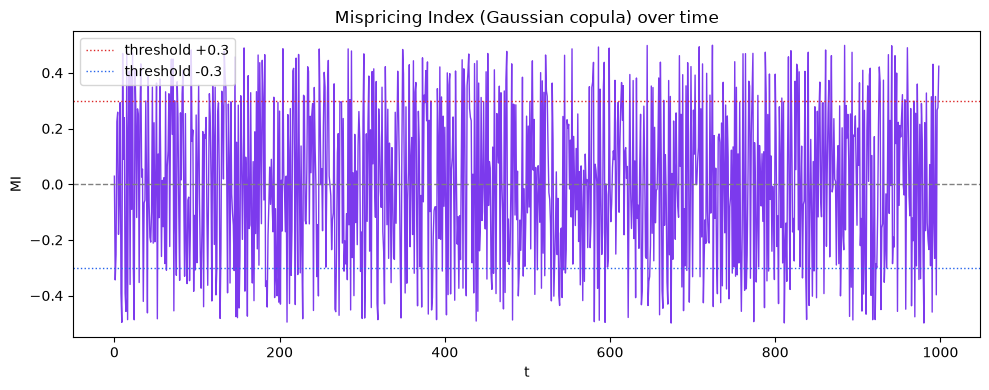

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mi, color="#7c3aed", linewidth=1)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axhline(0.3, color="#dc2626", linestyle=":", linewidth=1, label="threshold +0.3")
ax.axhline(-0.3, color="#2563eb", linestyle=":", linewidth=1, label="threshold -0.3")
ax.set_title("Mispricing Index (Gaussian copula) over time")
ax.set_xlabel("t"); ax.set_ylabel("MI")
ax.legend()
plt.tight_layout()
plt.savefig("copula_mispricing_index.png", dpi=110)
plt.show()


## สรุป

- Engle-Granger + ADF แยกคู่ cointegrate จริงจาก spurious pair ได้ในตัวอย่างนี้ — แต่ §2.4 พิสูจน์ว่าเมื่อสแกนเยอะ ๆ จะมี "คู่ผี" ผ่านโดยบังเอิญเสมอในสัดส่วนที่คณิตศาสตร์ทำนายได้
- Half-life กับ Hurst ที่ประมาณได้ควรใกล้เคียงค่าจริงที่เรารู้อยู่แล้ว (เพราะข้อมูลจำลอง) — ถ้าใช้ข้อมูลจริงจะไม่มี "ค่าจริง" ให้เทียบ ต้องอาศัย out-of-sample validation แทน (Part IX)
- Copula MI ให้สัญญาณคนละแบบจาก z-score ของ cointegration — คุ้มเวลาที่ cointegration แบบเชิงเส้นเริ่มพัง แต่ยังต้อง out-of-sample เสมอ (Part II §2.4 กับดัก)

⚠️ Gaussian copula ในสาธิตนี้**ไม่มี tail dependence** (โดยนิยาม) — ถ้าอยากเห็น tail dependence ต้องใช้ Clayton/Gumbel/Student-t ซึ่งไม่มีสูตร conditional CDF ปิดรูปง่าย ๆ แบบนี้ (ต้องพึ่ง numerical fitting เช่น `copulas`/`arbitragelab` ตามที่ Part II แนะนำ) — โค้ดชุดนี้จึงเป็น *ตัวอย่างกลไก* ไม่ใช่กลยุทธ์พร้อมใช้งานจริง
